In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rafayel404","key":"86bf30f360a5252916f72eabaafcb5ff"}'}

In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:50<00:00, 22.9MB/s]



In [ ]:
!unzip /content/dogsvscats.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dogs/dog.4419.jpg  
  inflating: /content/train/dogs/dog.442.jpg  
  inflating: /content/train/dogs/dog.4420.jpg  
  inflating: /content/train/dogs/dog.4421.jpg  
  inflating: /content/train/dogs/dog.4422.jpg  
  inflating: /content/train/dogs/dog.4424.jpg  
  inflating: /content/train/dogs/dog.4425.jpg  
  inflating: /content/train/dogs/dog.4426.jpg  
  inflating: /content/train/dogs/dog.4427.jpg  
  inflating: /content/train/dogs/dog.4431.jpg  
  inflating: /content/train/dogs/dog.4433.jpg  
  inflating: /content/train/dogs/dog.4436.jpg  
  inflating: /content/train/dogs/dog.4438.jpg  
  inflating: /content/train/dogs/dog.4439.jpg  
  inflating: /content/train/dogs/dog.444.jpg  
  inflating: /content/train/dogs/dog.4440.jpg  
  inflating: /content/train/dogs/dog.4441.jpg  
  inflating: /content/train/dogs/dog.4442.jpg  
  inflating: /content/train/dogs/dog.4443.jpg  
  inflating: /content/train/dogs/dog.44

# Importing Packages

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
from keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

In [ ]:
cat_directory_path='/content/catsvsdogs/train/cats'
dog_directory_path='/content/catsvsdogs/train/dogs'

In [ ]:
os.listdir(cat_directory_path)

['cat.7399.jpg',
 'cat.1115.jpg',
 'cat.5919.jpg',
 'cat.2609.jpg',
 'cat.10193.jpg',
 'cat.2272.jpg',
 'cat.8150.jpg',
 'cat.3139.jpg',
 'cat.2812.jpg',
 'cat.8936.jpg',
 'cat.1486.jpg',
 'cat.9194.jpg',
 'cat.231.jpg',
 'cat.10044.jpg',
 'cat.5246.jpg',
 'cat.725.jpg',
 'cat.2572.jpg',
 'cat.6218.jpg',
 'cat.10311.jpg',
 'cat.3279.jpg',
 'cat.1141.jpg',
 'cat.5050.jpg',
 'cat.3168.jpg',
 'cat.10671.jpg',
 'cat.1308.jpg',
 'cat.12264.jpg',
 'cat.1207.jpg',
 'cat.12327.jpg',
 'cat.10567.jpg',
 'cat.12061.jpg',
 'cat.4943.jpg',
 'cat.9642.jpg',
 'cat.5482.jpg',
 'cat.7181.jpg',
 'cat.606.jpg',
 'cat.5097.jpg',
 'cat.8492.jpg',
 'cat.10709.jpg',
 'cat.8774.jpg',
 'cat.1040.jpg',
 'cat.12406.jpg',
 'cat.11066.jpg',
 'cat.5911.jpg',
 'cat.6410.jpg',
 'cat.6912.jpg',
 'cat.6972.jpg',
 'cat.9483.jpg',
 'cat.8956.jpg',
 'cat.2354.jpg',
 'cat.3138.jpg',
 'cat.1143.jpg',
 'cat.7849.jpg',
 'cat.7737.jpg',
 'cat.3650.jpg',
 'cat.11905.jpg',
 'cat.10670.jpg',
 'cat.11808.jpg',
 'cat.63.jpg',
 'cat

In [ ]:
len(os.listdir(cat_directory_path))

10000

In [ ]:
len(os.listdir(dog_directory_path))

10000

array([[[ 75, 112, 140],
        [ 75, 112, 140],
        [ 79, 116, 144],
        ...,
        [ 54,  77, 127],
        [ 58,  77, 120],
        [ 32,  49,  88]],

       [[ 71, 108, 136],
        [ 72, 109, 137],
        [ 78, 115, 143],
        ...,
        [ 56,  79, 129],
        [ 68,  87, 130],
        [ 22,  39,  78]],

       [[ 53,  88, 114],
        [ 55,  90, 116],
        [ 63,  98, 124],
        ...,
        [ 44,  67, 117],
        [ 70,  89, 134],
        [  3,  21,  62]],

       ...,

       [[ 68,  78,  85],
        [ 55,  65,  72],
        [ 43,  54,  62],
        ...,
        [ 52,  80,  91],
        [ 54,  78,  90],
        [ 55,  79,  91]],

       [[ 56,  66,  73],
        [ 46,  56,  63],
        [ 39,  50,  58],
        ...,
        [ 70,  98, 109],
        [ 66,  90, 102],
        [ 61,  85,  97]],

       [[ 49,  59,  66],
        [ 42,  52,  59],
        [ 38,  49,  57],
        ...,
        [ 70,  98, 109],
        [ 59,  83,  95],
        [ 54,  78,  90]]], dtype=uint8)
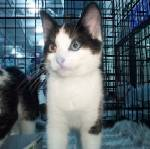

In [ ]:
random_cat='/content/catsvsdogs/train/cats/cat.1000.jpg'
import cv2
img=cv2.imread(random_cat,)
img

array([[[ 39, 181, 146],
        [ 21, 165, 130],
        [  9, 158, 124],
        ...,
        [ 28, 159, 132],
        [ 37, 168, 141],
        [ 47, 178, 151]],

       [[ 40, 182, 147],
        [ 38, 182, 147],
        [ 16, 165, 131],
        ...,
        [ 38, 171, 144],
        [ 50, 183, 156],
        [ 68, 201, 174]],

       [[ 37, 179, 144],
        [ 52, 196, 161],
        [ 21, 170, 136],
        ...,
        [ 47, 183, 155],
        [ 53, 189, 161],
        [ 67, 203, 175]],

       ...,

       [[ 33, 141, 123],
        [ 39, 147, 129],
        [  9, 116,  97],
        ...,
        [ 78, 190, 166],
        [ 51, 161, 137],
        [ 67, 177, 153]],

       [[ 49, 153, 136],
        [ 58, 162, 145],
        [ 30, 135, 116],
        ...,
        [ 52, 162, 136],
        [ 23, 132, 106],
        [ 35, 144, 118]],

       [[ 65, 167, 150],
        [ 70, 172, 155],
        [ 52, 154, 136],
        ...,
        [ 62, 173, 145],
        [ 31, 138, 111],
        [ 41, 148, 121]]], dtype=uint8)
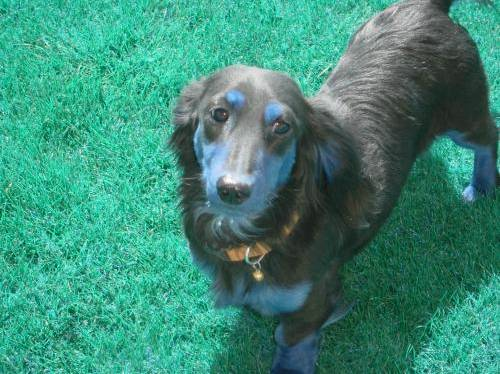

In [ ]:
random_dog='/content/catsvsdogs/test/dogs/dog.10032.jpg'
img=cv2.imread(random_dog)
img

# Data analysis


In [ ]:
cat_images = os.listdir(cat_directory_path)
dog_images = os.listdir(dog_directory_path)

classes_animals = ['Cats', 'Dogs']
count = [len(cat_images), len(dog_images)]

print(count)

[10000, 10000]


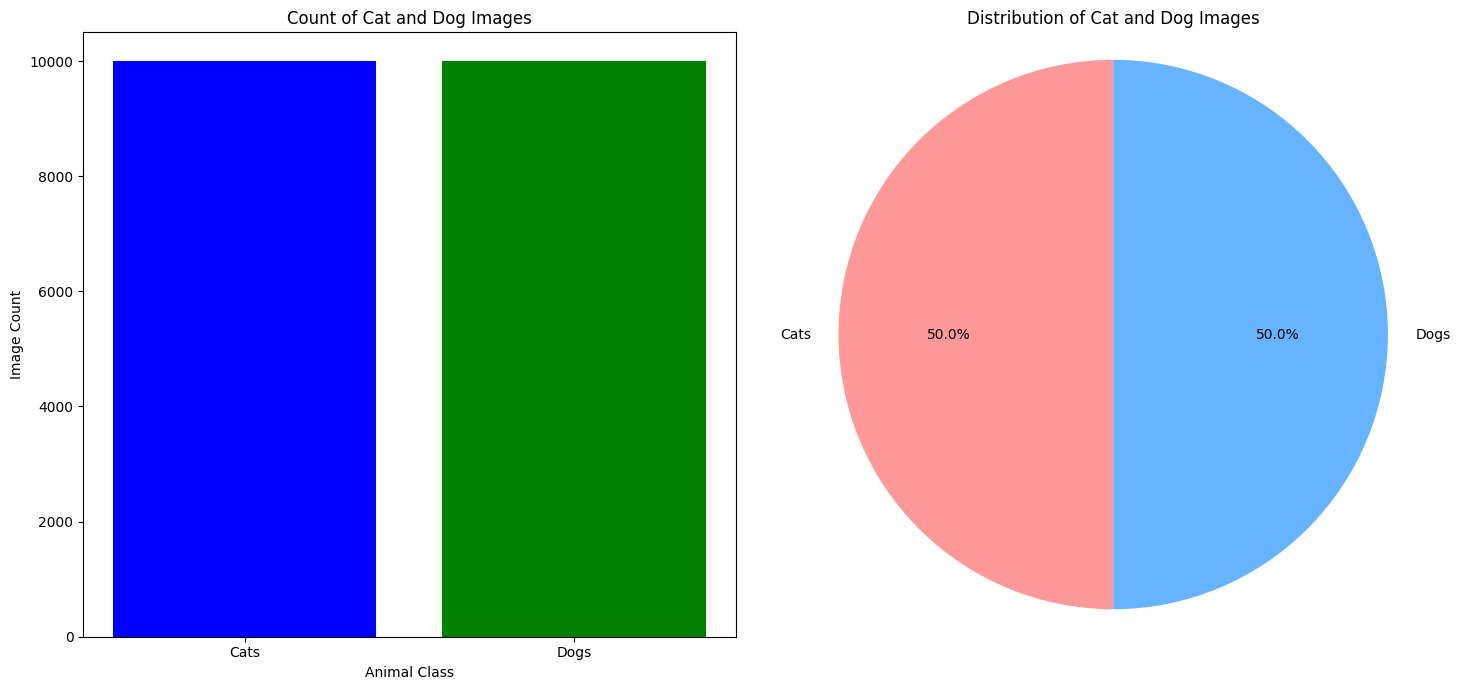

In [ ]:
# Creating both a bar chart and a pie chart side by side in a single figure

# Setting up a figure and axes for two subplots: one for the bar chart, one for the pie chart
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Bar chart on the first subplot
ax[0].bar(classes_animals, count, color=['blue', 'green'])
ax[0].set_xlabel('Animal Class')
ax[0].set_ylabel('Image Count')
ax[0].set_title('Count of Cat and Dog Images')

# Pie chart on the second subplot
colors = ['#ff9999','#66b3ff']
ax[1].pie(count, labels=classes_animals, colors=colors, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Distribution of Cat and Dog Images')
ax[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Adjust the layout so that both subplots fit nicely
plt.tight_layout()
plt.show()


 # Building model

In [ ]:
# Set path to the dataset
base_dir = '/content/catsvsdogs/train'

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [ ]:
 # Using 20% of data for validation
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),  # Resizing images to 150x150
    batch_size=20,
    class_mode='binary',  # Since we use binary_crossentropy loss, we need binary labels
    subset='training')  # Set as training data

validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary',
    subset='validation',
    shuffle=False  # Disable shuffling for validation data
)

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


In [ ]:
# Accessing class labels for the training data
train_class_labels = train_generator.class_indices
print("Training class labels:", train_class_labels)

# Accessing class labels for the validation data
validation_class_labels = validation_generator.class_indices
print("Validation class labels:", validation_class_labels)

Training class labels: {'cats': 0, 'dogs': 1}
Validation class labels: {'cats': 0, 'dogs': 1}


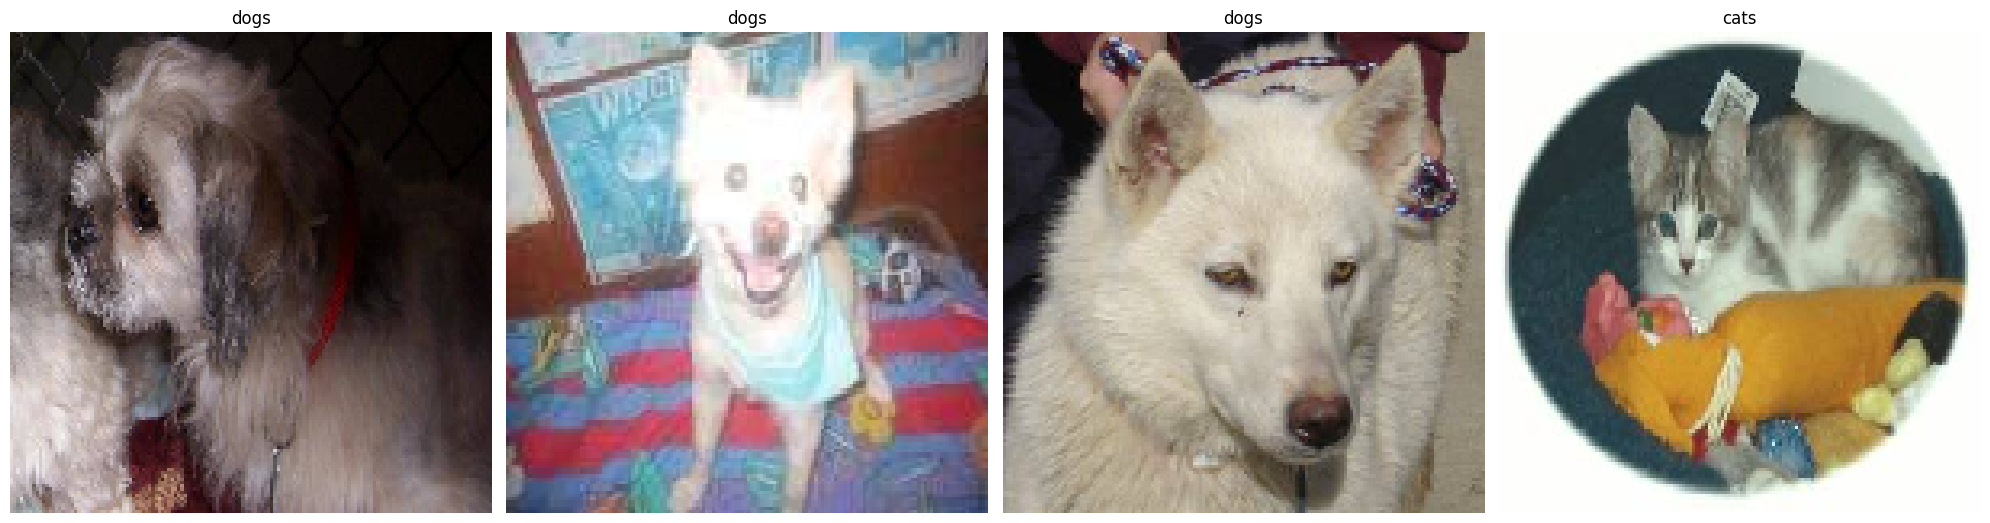

In [ ]:
import matplotlib.pyplot as plt

# Function to plot images and their labels
def plot_images_from_generator(generator, num_images=4):
    # Get a batch of images and labels from the generator
    images, labels = next(generator)

    # Set up the plot
    fig, axes = plt.subplots(1, num_images, figsize=(20,20))
    axes = axes.flatten()

    for img, label, ax in zip(images, labels, axes):
        # Image preprocessing might differ, adjust accordingly
        ax.imshow(img)
        # Set the title to the class label
        # Inverse the class indices dictionary to get class names from labels
        class_labels = dict((v,k) for k,v in generator.class_indices.items())
        ax.set_title(class_labels[int(label)])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Now, call this function with your training generator
plot_images_from_generator(train_generator, num_images=4)

#  Basic CNN Model

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential()

# Adding layers one by one
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))  # Sigmoid activation for binary classification

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

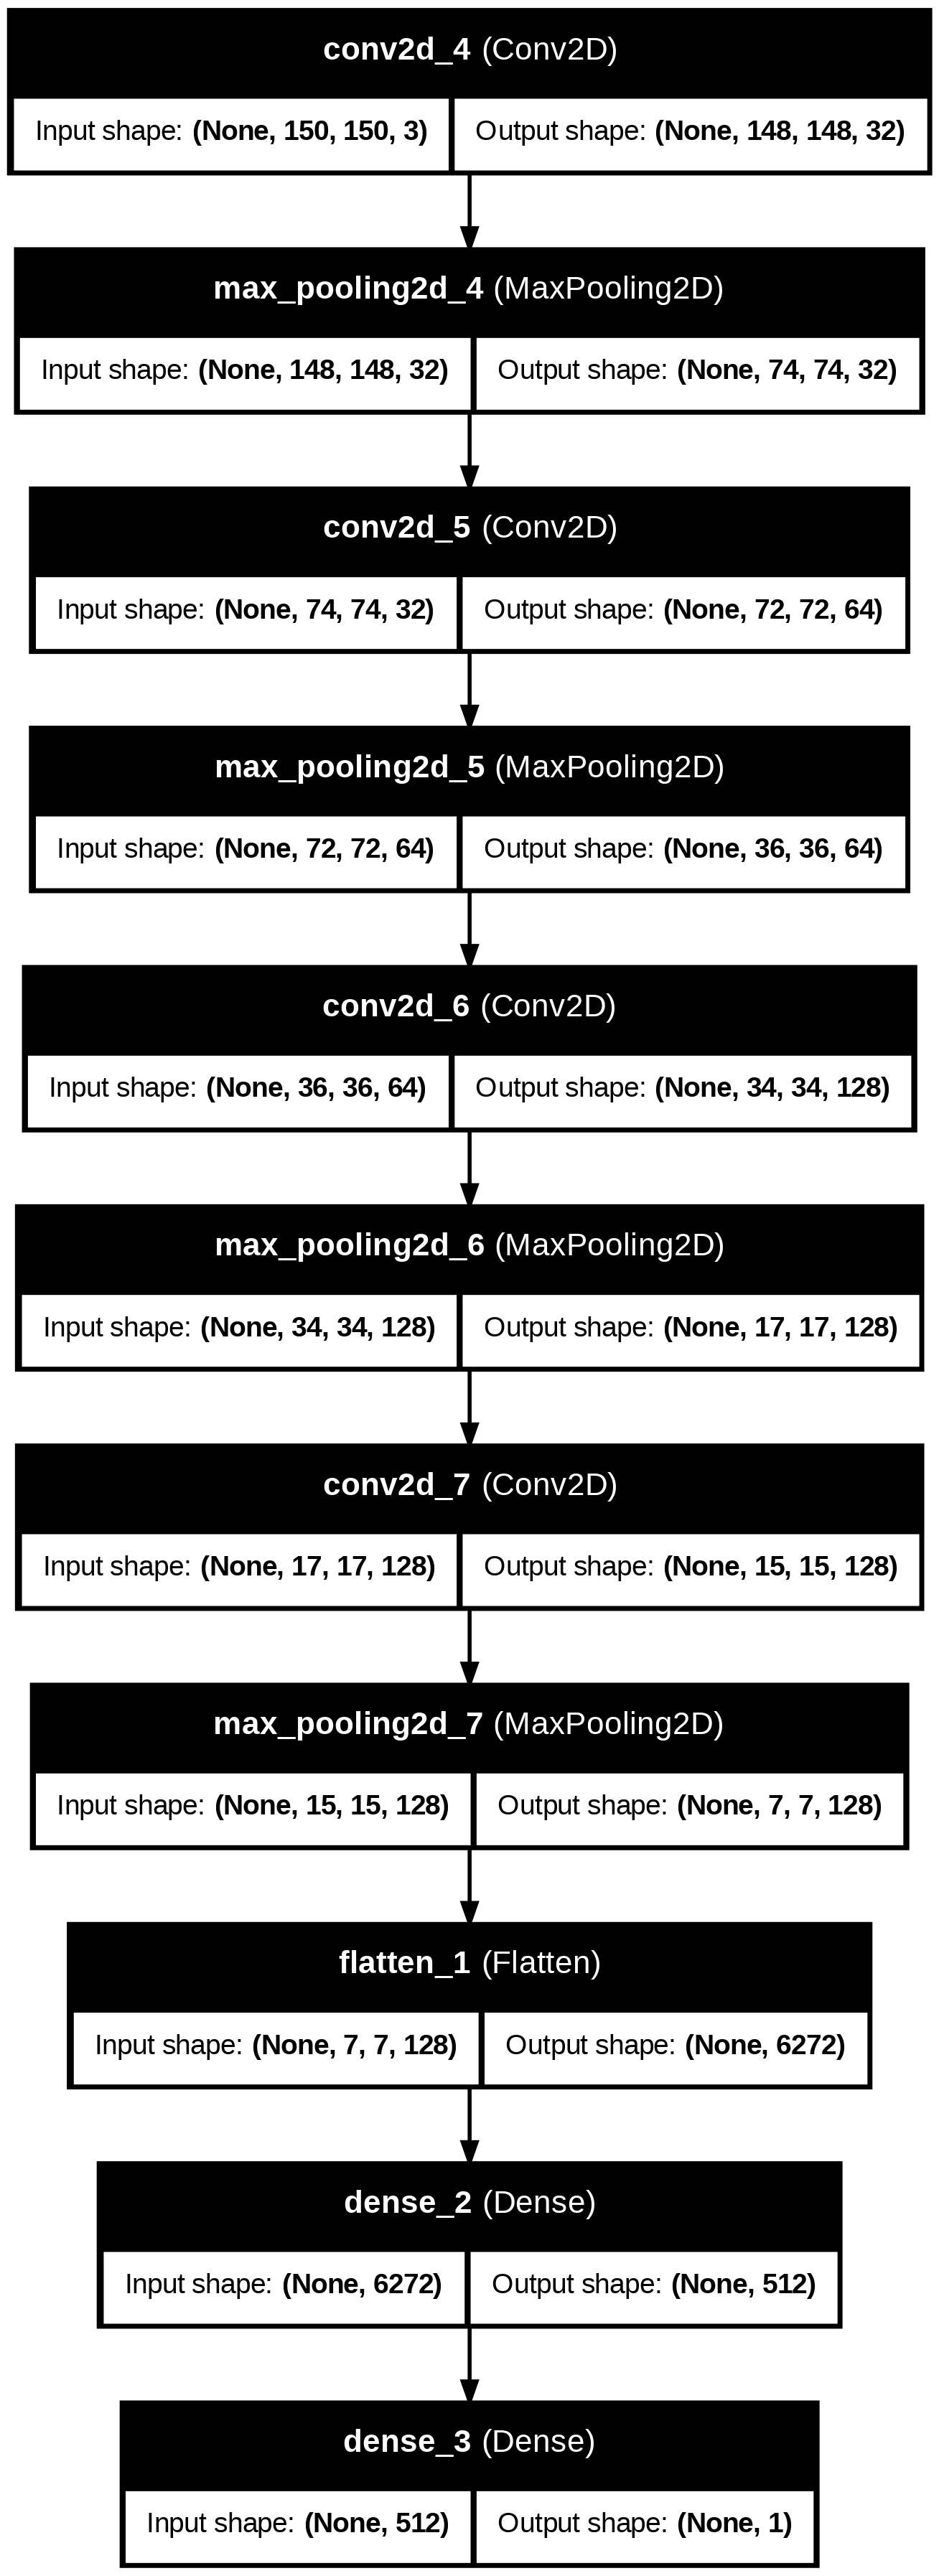

In [ ]:
plot_model(model, to_file = 'Architecture.png',
           show_shapes=True, show_layer_names=True)

## Parameter Calculation in CNN Layers

### Conv2D Layer

The formula to calculate the number of parameters in a Conv2D layer is:

$$\text{Parameters} = (\text{kernel\_height} \times \text{kernel\_width} \times \text{input\_channels} + 1) \times \text{number\_of\_filters}$$

The "+1" accounts for the bias term for each filter.

#### 1. First Conv2D Layer

- Input shape: (150, 150, 3)
- Number of filters: 32
- Filter size: (3, 3)
- Parameters: $$(3 \times 3 \times 3 + 1) \times 32 = 896$$

#### 2. Second Conv2D Layer

- Input channels: 32 (from the previous Conv2D layer)
- Number of filters: 64
- Filter size: (3, 3)
- Parameters: $$(3 \times 3 \times 32 + 1) \times 64 = 18,496$$

#### 3. Third Conv2D Layer

- Input channels: 64
- Number of filters: 128
- Filter size: (3, 3)
- Parameters: $$(3 \times 3 \times 64 + 1) \times 128 = 73,856$$

#### 4. Fourth Conv2D Layer

- Input channels: 128
- Number of filters: 128
- Filter size: (3, 3)
- Parameters: $$(3 \times 3 \times 128 + 1) \times 128 = 147,584$$

### MaxPooling2D Layer

MaxPooling layers do not have parameters; they only reduce the size of the input they're applied to, based on their pool size and stride.

### Flatten Layer

The Flatten layer itself doesn't have parameters. It simply reshapes the input but does not affect the total parameter count.

### Dense Layer

The formula for a Dense (fully connected) layer is:

$$\text{Parameters} = (\text{input\_size} + 1) \times \text{output\_size}$$

#### 1. First Dense Layer

- Assuming Flatten output size: X (you'll need to calculate this based on the output of the last pooling layer).
- Output size: 512
- Parameters: $$(X + 1) \times 512$$

#### 2. Second Dense Layer

- Input size: 512
- Output size: 1 (for binary classification)
- Parameters: $$(512 + 1) \times 1 = 513$$


In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary',
    subset='validation',
    shuffle=False  # Disable shuffling for validation data
)


Found 4000 images belonging to 2 classes.


In [ ]:
# Set the number of epochs
epochs = 20

# You can use this but keras automatically caluclates the steps per epoch so you dont need to do it.
'''
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

'''
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.5873 - loss: 0.6624 - val_accuracy: 0.6457 - val_loss: 0.6207
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.7434 - loss: 0.5226 - val_accuracy: 0.7843 - val_loss: 0.4619
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.8005 - loss: 0.4271 - val_accuracy: 0.8077 - val_loss: 0.4104
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.8394 - loss: 0.3573 - val_accuracy: 0.8292 - val_loss: 0.3797
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8760 - loss: 0.2925 - val_accuracy: 0.8435 - val_loss: 0.3559
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9050 - loss: 0.2249 - val_accuracy: 0.8608 - val_loss: 0.3512
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.9317 - loss: 0.1661 - val_accuracy: 0.8587 - val_loss: 0.3778
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9557 - loss: 0.1090 - 

In [ ]:
history

In [ ]:
history.history

{'accuracy': [0.5873125195503235,
  0.7434375286102295,
  0.8004999756813049,
  0.8394374847412109,
  0.8759999871253967,
  0.9049999713897705,
  0.9317499995231628,
  0.9556875228881836,
  0.9683125019073486,
  0.9754375219345093,
  0.9821875095367432,
  0.9858750104904175,
  0.9866874814033508,
  0.9888125061988831,
  0.9864374995231628,
  0.9902499914169312,
  0.9910625219345093,
  0.9915000200271606,
  0.9865624904632568,
  0.9913750290870667],
 'loss': [0.6623685359954834,
  0.522624135017395,
  0.42714300751686096,
  0.3573131859302521,
  0.29254618287086487,
  0.22487349808216095,
  0.16612333059310913,
  0.10901802778244019,
  0.07984822988510132,
  0.0653052106499672,
  0.05126085504889488,
  0.04146004095673561,
  0.04033155366778374,
  0.03339727967977524,
  0.03875477984547615,
  0.030442269518971443,
  0.027568915858864784,
  0.027224013581871986,
  0.04299638792872429,
  0.027052082121372223],
 'val_accuracy': [0.6457499861717224,
  0.784250020980835,
  0.8077499866485596

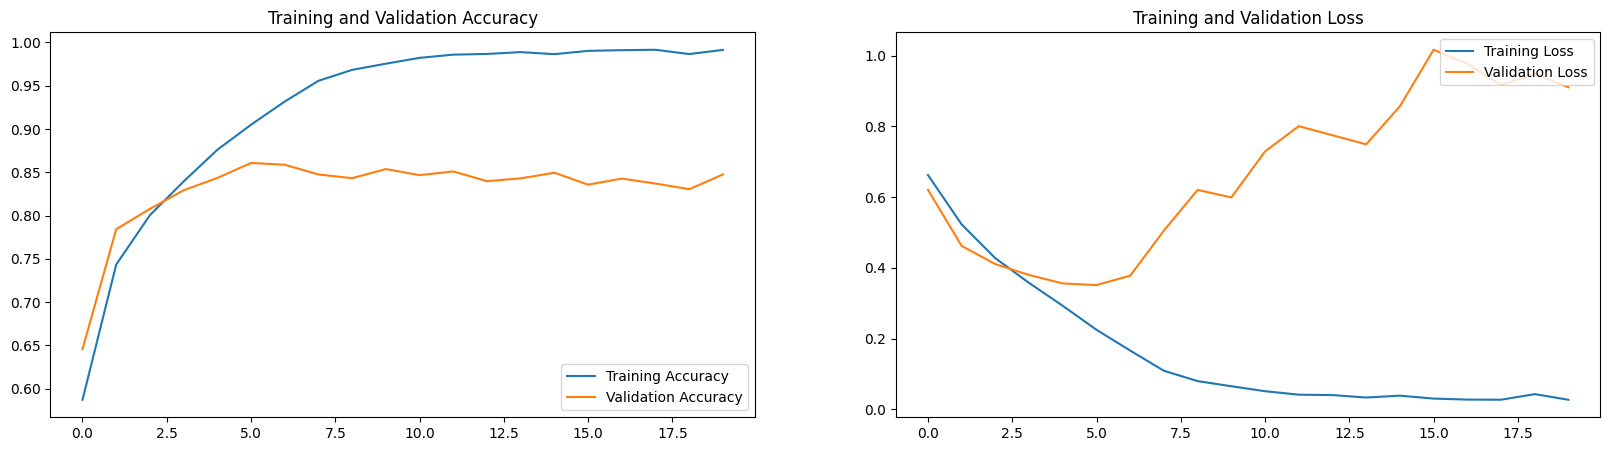

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Model Evaluation

Initializing test generator

In [ ]:
# Define the test data generator
test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescaling for test data

test_dir = '/content/catsvsdogs/test'  # Path to your test directory

# Create the test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),  # Should match the input size of your network
    batch_size=20,  # Can adjust based on your memory constraints
    class_mode='binary',  # We do not need the labels here
    shuffle=False)  # Do not shuffle to maintain the order of files

Found 5000 images belonging to 2 classes.


In [ ]:
# Evaluating the model
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator))

print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8540 - loss: 0.8432
Test Loss: 0.8432369232177734
Test Accuracy: 0.8539999723434448


# Making prediction

In [ ]:
np.ceil(test_generator.samples/test_generator.batch_size)

np.float64(250.0)

In [ ]:
probabilities = model.predict(test_generator)
probabilities

250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step


array([[1.4707713e-05],
       [7.7053036e-10],
       [4.6233328e-09],
       ...,
       [9.9999988e-01],
       [7.7786601e-01],
       [9.9999893e-01]], dtype=float32)

In [ ]:
steps = int(np.ceil(test_generator.samples / test_generator.batch_size))

probabilities = model.predict(
    test_generator,
    steps=steps
)

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step


In [ ]:
probabilities

array([[1.4707713e-05],
       [7.7053036e-10],
       [4.6233328e-09],
       ...,
       [9.9999988e-01],
       [7.7786601e-01],
       [9.9999893e-01]], dtype=float32)

In [ ]:
# Predict probabilities for the positive class
probabilities = model.predict(test_generator,
                              steps=int(test_generator.samples / test_generator.batch_size))

# The output is the probability of the positive class (assuming binary classification),
# so we will threshold it at 0.5 to decide the predicted class
predicted_classes = (probabilities > 0.5).astype(int).squeeze()

# To match with the filenames or other identifiers, you can extract the file names from the generator
filenames = test_generator.filenames

# If you need the actual class labels instead of 0/1, you can map the predicted classes back to the original labels
class_labels = list(test_generator.class_indices.keys())
predicted_labels = [class_labels[i] for i in predicted_classes]

# Now you can inspect the results:
for i in range(len(filenames)):
    print(f"File: {filenames[i]} - Predicted: {predicted_labels[i]}")

Streaming output truncated to the last 5000 lines.
File: cats/cat.10.jpg - Predicted: cats
File: cats/cat.10000.jpg - Predicted: cats
File: cats/cat.10001.jpg - Predicted: cats
File: cats/cat.10007.jpg - Predicted: cats
File: cats/cat.10017.jpg - Predicted: dogs
File: cats/cat.10021.jpg - Predicted: cats
File: cats/cat.10026.jpg - Predicted: dogs
File: cats/cat.10030.jpg - Predicted: cats
File: cats/cat.10033.jpg - Predicted: cats
File: cats/cat.10035.jpg - Predicted: dogs
File: cats/cat.10036.jpg - Predicted: cats
File: cats/cat.10046.jpg - Predicted: cats
File: cats/cat.10048.jpg - Predicted: cats
File: cats/cat.10052.jpg - Predicted: cats
File: cats/cat.10057.jpg - Predicted: cats
File: cats/cat.10064.jpg - Predicted: cats
File: cats/cat.10074.jpg - Predicted: cats
File: cats/cat.10086.jpg - Predicted: cats
File: cats/cat.10091.jpg - Predicted: cats
File: cats/cat.10105.jpg - Predicted: cats
File: cats/cat.10109.jpg - Predicted: cats
File: cats/cat.10110.jpg - Predicted: cats
File: 

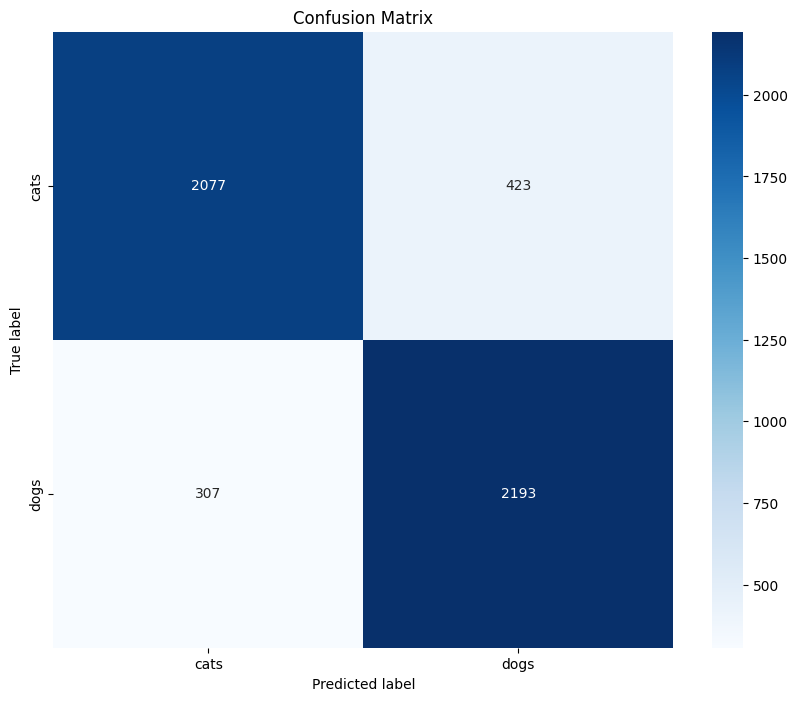

In [ ]:
# Get the true labels from the test generator
true_classes = test_generator.classes

# Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plotting with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Inference

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(test_generator)

# Print the results
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Test loss: {loss:.2f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.8540 - loss: 0.8432
Test accuracy: 85.40%
Test loss: 0.84


In [ ]:
def make_prediction(image_path):
    img = load_img(img_path, target_size=(150, 150))  # Resizing the image
    img_array = img_to_array(img)  # Converting to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.  # Rescale the image similarly as we did for the training data

    prediction = model.predict(img_array)
    print("Prediction:", prediction)

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    # Prediction
    plt.subplot(1, 2, 2)
    if prediction[0][0] > 0.5:
        plt.title('Predicted: Dog')
    else:
        plt.title('Predicted: Cat')
    plt.imshow(img)  # Show the same image as prediction
    plt.axis('off')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
Prediction: [[4.623333e-09]]


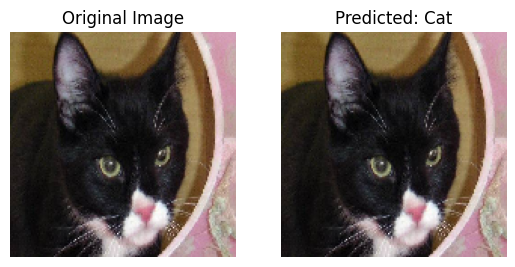

In [ ]:
# Load and preprocess the image
img_path = '/content/catsvsdogs/test/cats/cat.10001.jpg'
make_prediction(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: [[0.9999999]]


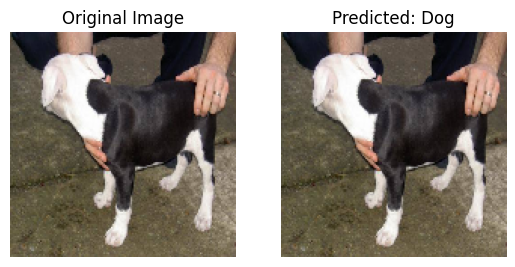

In [ ]:
# Load and preprocess the image
img_path = '/content/catsvsdogs/test/dogs/dog.10022.jpg'
make_prediction(img_path)

# Misclassification

In [ ]:
# Reset the test_generator before making predictions
test_generator.reset()

# Predict the whole test set
predictions = model.predict(test_generator, verbose=1)

# The predictions will be in the format of probabilities. You'll need to convert these to binary labels (0 or 1) based on a 0.5 threshold.
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)
true_classes = test_generator.classes
misclassified_indices = np.where(predicted_classes != true_classes)[0]
misclassified_count = len(misclassified_indices)
print(f"Total misclassifications in the test set: {misclassified_count} out of {len(true_classes)}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step
Total misclassifications in the test set: 730 out of 5000


250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step
Total misclassifications: 730


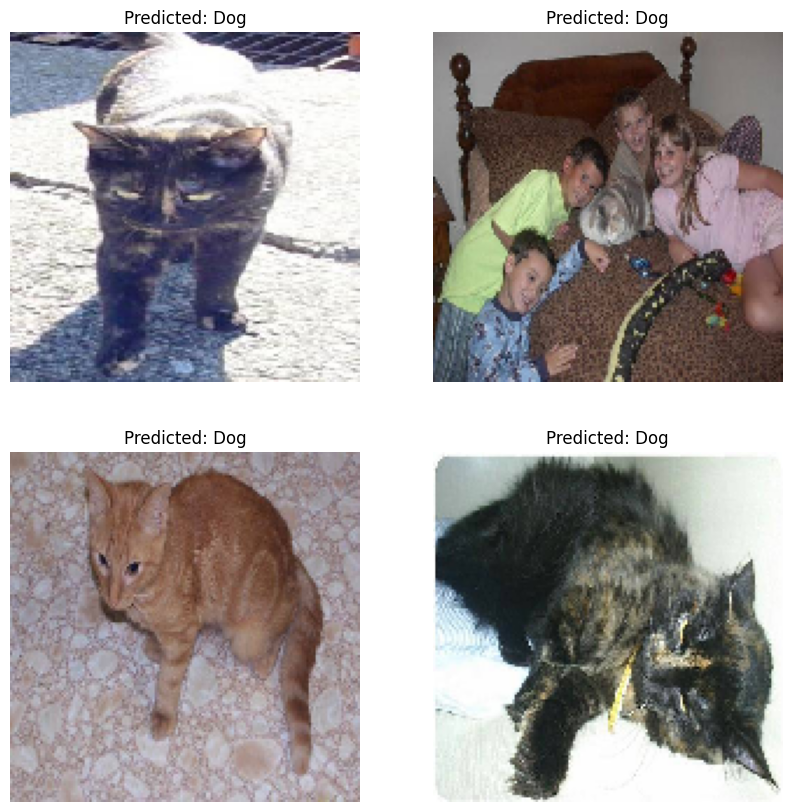

In [ ]:
# Generate predictions for all test images
predictions = model.predict(test_generator)
# Convert predictions to binary (0 or 1) based on a 0.5 threshold
predicted_classes = predictions > 0.5

# Retrieve the true labels from the generator
true_classes = test_generator.classes

# Filenames can also be useful for debugging
filenames = test_generator.filenames
# Identifying indices of misclassified images
misclassified_indices = np.where(predicted_classes.flatten() != true_classes)[0]

print(f"Total misclassifications: {len(misclassified_indices)}")


# Select a random subset of misclassified images
num_samples_to_display = 4
random_indices = random.sample(list(misclassified_indices), num_samples_to_display)

# Plot
plt.figure(figsize=(10, 10))
for i, index in enumerate(random_indices, 1):
    # Load image
    img_path = test_dir + '/' + filenames[index]
    img = load_img(img_path, target_size=(150, 150))

    # Predicted class
    predicted_class = "Dog" if predicted_classes[index] else "Cat"

    # Display
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
plt.show()